# 📝 Notebook 03b — TF-IDF Exploration

**Purpose:** Identify words in `blurb` (short description) and `name` (campaign title) that are strongly associated with campaign success or failure.

**Workflow:**
1. Fit TF-IDF on **training data only**
2. For each term, compute the **success rate** of campaigns that contain it
3. Rank terms by association with success/failure
4. Export a shortlist of predictive words → used in `03a_feature_engineering.ipynb` as binary features

**Key principle:** Term selection is based on training data only. The resulting word list is then applied to both train and test splits in notebook 03a.

> ⚠️ **Run this notebook (03b) BEFORE 03a.** Notebook 03a loads `tfidf_word_list.json` produced here.

## Setup

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

OUTPUTS_PATH = 'data'   # reads from notebook 01; saves tfidf_word_list.json here
FIGURES_PATH = os.path.join(OUTPUTS_PATH, 'figures')
os.makedirs(FIGURES_PATH, exist_ok=True)

train_df = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'train_df.parquet'))
test_df  = pd.read_parquet(os.path.join(OUTPUTS_PATH, 'test_df.parquet'))

print(f'Train: {train_df.shape}')
print(f'Test : {test_df.shape}')

Train: (120594, 18)
Test : (37686, 18)


## Step 1 — TF-IDF on `blurb`

We fit TF-IDF on training data only with the following settings:
- `min_df=50`: a word must appear in at least 50 campaigns to be included (avoids rare noise)
- `max_df=0.8`: ignore words appearing in more than 80% of campaigns (too common to be informative)
- `ngram_range=(1,2)`: include single words and two-word phrases
- `stop_words='english'`: remove common English stop words

In [2]:
blurb_train = train_df['blurb'].fillna('').astype(str)
blurb_test  = test_df['blurb'].fillna('').astype(str)

# Fit on training data only
tfidf_blurb = TfidfVectorizer(
    min_df=50,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)
X_blurb_train = tfidf_blurb.fit_transform(blurb_train)
X_blurb_test  = tfidf_blurb.transform(blurb_test)

vocab_blurb = tfidf_blurb.get_feature_names_out()
print(f'Vocabulary size (blurb): {len(vocab_blurb):,} terms')
print(f'Matrix shape (train)   : {X_blurb_train.shape}')

Vocabulary size (blurb): 4,477 terms
Matrix shape (train)   : (120594, 4477)


## Step 2 — Success Rate per Term (blurb)

For each term, we compute:
- `n`: number of campaigns whose blurb contains the term
- `success_rate`: mean success rate among those campaigns
- `lift`: success_rate / global_mean — how much better/worse than average
- `z_score` / `p_value`: statistical significance of the difference from global mean

In [3]:
y_train = train_df['success'].values
global_mean = y_train.mean()
print(f'Global success rate: {global_mean*100:.1f}%')

# Binary presence matrix (1 = term appears in blurb)
presence = (X_blurb_train > 0).toarray()

rows = []
for i, term in enumerate(vocab_blurb):
    mask = presence[:, i]
    n = mask.sum()
    if n < 50:
        continue
    sr = y_train[mask].mean()
    # Two-proportion z-test vs global mean
    from statsmodels.stats.proportion import proportions_ztest
    z, p = proportions_ztest(y_train[mask].sum(), n, value=global_mean)
    rows.append({'term': term, 'n': int(n), 'success_rate': sr, 'lift': sr / global_mean, 'z': z, 'p_value': p})

blurb_stats = pd.DataFrame(rows).sort_values('success_rate', ascending=False)
print(f'Terms analysed: {len(blurb_stats):,}')
print(f'Significant (p<0.01): {(blurb_stats["p_value"] < 0.01).sum():,}')

Global success rate: 59.7%
Terms analysed: 4,477
Significant (p<0.01): 1,965


## Step 3 — Top Predictive Terms (blurb)

In [4]:
# Filter: significant (p<0.01) and at least 200 campaigns
sig = blurb_stats[blurb_stats['p_value'] < 0.01].copy()

top_positive = sig[sig['lift'] > 1].nlargest(20, 'lift')
top_negative = sig[sig['lift'] < 1].nsmallest(20, 'lift')

print('=== Top 20 terms associated with SUCCESS (blurb) ===')
print(top_positive[['term','n','success_rate','lift','p_value']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              lift=lambda x: x['lift'].round(3),
              p_value=lambda x: x['p_value'].apply(lambda v: f'{v:.2e}'))
      .to_string(index=False))

print()
print('=== Top 20 terms associated with FAILURE (blurb) ===')
print(top_negative[['term','n','success_rate','lift','p_value']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              lift=lambda x: x['lift'].round(3),
              p_value=lambda x: x['p_value'].apply(lambda v: f'{v:.2e}'))
      .to_string(index=False))

=== Top 20 terms associated with SUCCESS (blurb) ===
              term   n  success_rate  lift   p_value
      stretch goal  83         100.0 1.676  0.00e+00
        indie folk  50         100.0 1.676  0.00e+00
     chamber music  79         100.0 1.676  0.00e+00
        comedy web  95          98.9 1.659 3.68e-308
    evening length  66          98.5 1.651 4.87e-147
length documentary  58          98.3 1.647 4.86e-113
    string quartet  55          98.2 1.646 1.87e-101
    animated short 108          98.1 1.645 1.81e-193
      short comedy  52          98.1 1.644  1.67e-90
         new works  74          97.3 1.631  1.05e-88
 short documentary  68          97.1 1.627  1.90e-74
      mockumentary  66          97.0 1.625  5.59e-70
        watercolor  91          96.7 1.621  3.42e-87
             cello  89          96.6 1.620  3.20e-83
       stop motion 118          96.6 1.619 5.13e-109
           chamber 197          96.4 1.617 3.18e-171
     second length  80          96.2 1.613  1.

## Step 4 — Visualisation (blurb)

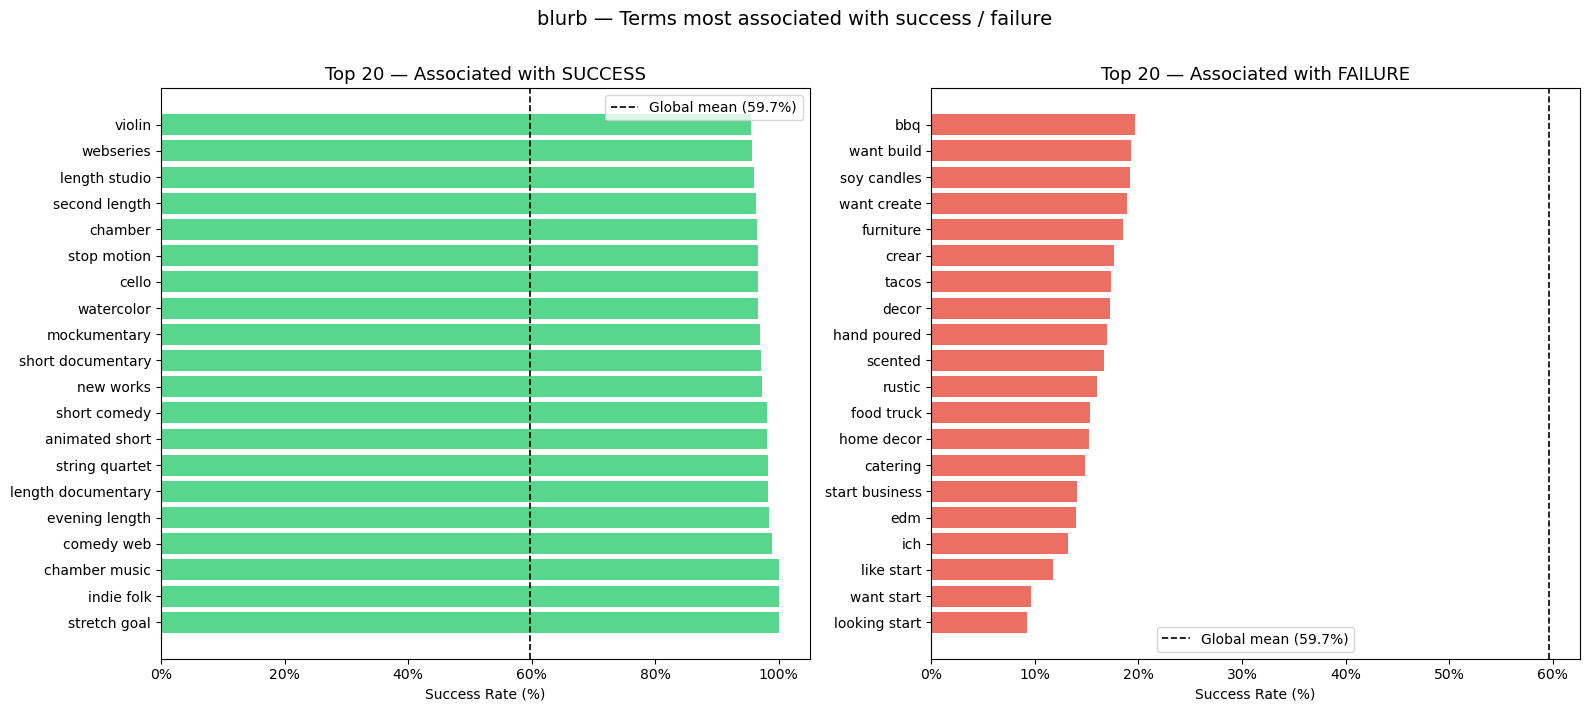

Saved tfidf_blurb_top_terms.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, title, color in [
    (axes[0], top_positive, 'Top 20 — Associated with SUCCESS', '#2ecc71'),
    (axes[1], top_negative.sort_values('lift'), 'Top 20 — Associated with FAILURE', '#e74c3c')
]:
    bars = ax.barh(data['term'], (data['success_rate'] * 100), color=color, alpha=0.8)
    ax.axvline(global_mean * 100, color='black', linestyle='--', linewidth=1.2, label=f'Global mean ({global_mean*100:.1f}%)')
    ax.set_xlabel('Success Rate (%)')
    ax.set_title(title, fontsize=13)
    ax.legend()
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('blurb — Terms most associated with success / failure', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'tfidf_blurb_top_terms.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved tfidf_blurb_top_terms.png')

## Step 5 — TF-IDF on `name` (campaign title)

In [6]:
name_train = train_df['name'].fillna('').astype(str)

tfidf_name = TfidfVectorizer(
    min_df=50,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)
X_name_train = tfidf_name.fit_transform(name_train)
vocab_name = tfidf_name.get_feature_names_out()
print(f'Vocabulary size (name): {len(vocab_name):,} terms')

presence_name = (X_name_train > 0).toarray()
rows_name = []
for i, term in enumerate(vocab_name):
    mask = presence_name[:, i]
    n = mask.sum()
    if n < 50:
        continue
    sr = y_train[mask].mean()
    z, p = proportions_ztest(y_train[mask].sum(), n, value=global_mean)
    rows_name.append({'term': term, 'n': int(n), 'success_rate': sr, 'lift': sr / global_mean, 'z': z, 'p_value': p})

name_stats = pd.DataFrame(rows_name).sort_values('success_rate', ascending=False)
sig_name = name_stats[name_stats['p_value'] < 0.01]

print()
print('=== Top 15 terms associated with SUCCESS (name) ===')
print(sig_name[sig_name['lift'] > 1].nlargest(15, 'lift')[['term','n','success_rate','lift','p_value']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              lift=lambda x: x['lift'].round(3),
              p_value=lambda x: x['p_value'].apply(lambda v: f'{v:.2e}'))
      .to_string(index=False))

print()
print('=== Top 15 terms associated with FAILURE (name) ===')
print(sig_name[sig_name['lift'] < 1].nsmallest(15, 'lift')[['term','n','success_rate','lift','p_value']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              lift=lambda x: x['lift'].round(3),
              p_value=lambda x: x['p_value'].apply(lambda v: f'{v:.2e}'))
      .to_string(index=False))

Vocabulary size (name): 1,721 terms

=== Top 15 terms associated with SUCCESS (name) ===
            term   n  success_rate  lift   p_value
  animated short 155          98.7 1.655  0.00e+00
  world premiere  73          97.3 1.630  3.07e-86
       paintings 180          97.2 1.630 1.48e-206
           emily  55          96.4 1.615  6.50e-48
       webseries 183          96.2 1.612 2.74e-146
     thesis film  51          96.1 1.611  6.04e-41
artist residency  75          96.0 1.609  4.73e-58
      new length  67          95.5 1.601  9.80e-46
       lovecraft  63          95.2 1.596  3.86e-40
   mural project  59          94.9 1.591  6.40e-35
       residency 194          94.8 1.590 7.20e-109
      3d printer 135          94.8 1.589  8.48e-76
documentary film  72          94.4 1.583  5.34e-38
         vermont  51          94.1 1.578  1.33e-25
       art nudes  68          94.1 1.578  1.39e-33

=== Top 15 terms associated with FAILURE (name) ===
         term   n  success_rate  lift   p_

## Step 6 — Category-Adjusted Diff & Export

Simply ranking by success rate risks selecting words that are high only because they appear in already-successful categories — a signal already captured by `cat_name_encoded`.

For each term we compute:
```
cat_avg_success = mean success rate of the categories that contain the term
diff = word_success_rate - cat_avg_success
```

A large positive `diff` means the word predicts success **beyond** what the category already explains.

**Selection criteria:**
- `p < 0.01` — statistically significant
- `n >= 200` — sufficient sample size
- `|diff| >= 10pt` — meaningful signal beyond category effect
- Year tokens (e.g. `2013`, `2012`) excluded — year effects were intentionally removed from the model
- Non-English tokens excluded (e.g. German: `und`, `ein`, `mit`; Spanish: `para`, `que`, `una`, `el`, `es`, `las`, `se`, `proyecto`; Italian: `di`) — these reflect the campaign's language rather than content, and language is already partially captured by `country_*` OHE features

In [7]:
import re

# Category success rate lookup (train only)
cat_success = train_df.groupby('cat_name')['success'].mean()

def add_diff(stats_df, presence_matrix, vocab_list, df_source):
    """Add cat_avg_success and diff columns to a stats DataFrame."""
    term_to_idx = {t: i for i, t in enumerate(vocab_list)}
    diffs = []
    for _, row in stats_df.iterrows():
        idx = term_to_idx.get(row['term'])
        if idx is None:
            diffs.append(np.nan)
            continue
        mask = presence_matrix[:, idx].astype(bool)
        cat_avg = df_source.loc[mask, 'cat_name'].map(cat_success).mean()
        diffs.append(row['success_rate'] - cat_avg)
    stats_df = stats_df.copy()
    stats_df['diff'] = diffs
    return stats_df

# Tokens to exclude
YEAR_PATTERN = re.compile(r'^\d{4}$')

# Non-English tokens: reflect language of campaign, not content.
# Language signal is partially captured by country_* OHE features.
NON_ENGLISH_TOKENS = {
    # German
    'und', 'ein', 'mit', 'ich', 'die', 'der', 'das',
    # Spanish
    'para', 'que', 'una', 'el', 'es', 'las', 'los', 'se', 'proyecto',
    # Italian
    'di', 'il', 'la', 'un',
}

def is_excluded(term):
    if YEAR_PATTERN.match(str(term)):
        return True
    # Check if any token in the term (could be bigram) is non-English
    tokens = str(term).lower().split()
    if any(t in NON_ENGLISH_TOKENS for t in tokens):
        return True
    return False

def shortlist(stats_df, presence_matrix, vocab_list, df_source, field,
              min_n=200, min_diff=0.10, p_thresh=0.01):
    df = add_diff(stats_df, presence_matrix, vocab_list, df_source)
    filtered = df[
        (df['p_value'] < p_thresh) &
        (df['n'] >= min_n) &
        (df['diff'].abs() >= min_diff) &
        (~df['term'].apply(is_excluded))
    ].copy()
    filtered['field'] = field
    return filtered.sort_values('diff', ascending=False)

blurb_vocab_list = list(tfidf_blurb.get_feature_names_out())
name_vocab_list  = list(tfidf_name.get_feature_names_out())

blurb_short = shortlist(blurb_stats, presence,      blurb_vocab_list, train_df, 'blurb')
name_short  = shortlist(name_stats,  presence_name, name_vocab_list,  train_df, 'name')

print(f'Shortlisted blurb terms: {len(blurb_short)}')
print(f'Shortlisted name  terms: {len(name_short)}')

print('\n=== BLURB — diff >= +10pt (success signal beyond category) ===')
pos_blurb = blurb_short[blurb_short['diff'] > 0]
print(pos_blurb[['term','n','success_rate','diff']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              diff=lambda x: (x['diff']*100).round(1))
      .to_string(index=False))

print('\n=== BLURB — diff <= -10pt (failure signal beyond category) ===')
neg_blurb = blurb_short[blurb_short['diff'] < 0].sort_values('diff')
print(neg_blurb[['term','n','success_rate','diff']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              diff=lambda x: (x['diff']*100).round(1))
      .to_string(index=False))

print('\n=== NAME — diff >= +10pt ===')
pos_name = name_short[name_short['diff'] > 0]
print(pos_name[['term','n','success_rate','diff']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              diff=lambda x: (x['diff']*100).round(1))
      .to_string(index=False))

print('\n=== NAME — diff <= -10pt ===')
neg_name = name_short[name_short['diff'] < 0].sort_values('diff')
print(neg_name[['term','n','success_rate','diff']]
      .assign(success_rate=lambda x: (x['success_rate']*100).round(1),
              diff=lambda x: (x['diff']*100).round(1))
      .to_string(index=False))

# Export
word_list = {
    'blurb': blurb_short[['term','n','success_rate','diff']].to_dict(orient='records'),
    'name' : name_short[['term','n','success_rate','diff']].to_dict(orient='records'),
}
with open(os.path.join(OUTPUTS_PATH, 'tfidf_word_list.json'), 'w') as f:
    json.dump(word_list, f, indent=2)
print('\nSaved tfidf_word_list.json')

Shortlisted blurb terms: 89
Shortlisted name  terms: 34

=== BLURB — diff >= +10pt (success signal beyond category) ===
           term   n  success_rate  diff
          queer 278          91.7  21.9
      edinburgh 292          84.6  19.2
         fringe 402          85.3  18.9
   raspberry pi 226          76.5  18.6
             pi 256          76.6  18.3
      raspberry 234          76.5  18.1
   neighborhood 254          74.8  16.7
        arduino 328          70.4  16.6
    burning man 278          90.3  16.0
           zine 380          79.2  15.7
    enamel pins 423          88.7  15.0
      residency 252          94.0  14.9
    hard enamel 222          87.4  14.7
         volume 359          81.3  14.7
limited edition 596          82.7  14.6
       brooklyn 282          84.8  14.5
           pins 644          85.4  13.9
        burning 330          83.6  13.6
          issue 421          74.3  13.5
    celebrating 587          81.8  13.3
        edition 951          81.0  13.1


## Next Step

Review the shortlisted terms above. Terms that make intuitive sense (e.g. genre words, effort signals) should be added as binary features in `03a_feature_engineering.ipynb`:

```python
# Example — to be added in notebook 03a after reviewing this output
for df in [train_df, val_df, test_df]:
    for term in selected_blurb_terms:
        col = 'blurb_has_' + term.replace(' ', '_')
        df[col] = df['blurb'].fillna('').str.contains(term, case=False, regex=False).astype(int)
```

**Important:** The term selection must be based on this notebook's output (training data only). Do not re-run term selection on the full dataset.